## Trabajo Práctico 4 - Estimación de parámetros

---

Simular una muestra de dos variables aleatorias $X_1$ y $X_2$ que siguen una distribución normal estándar. Calcular la varianza muestral $s^2$. Considerar dos estimadores diferentes de la desviación estándar $t_1 = \sqrt{s^2}$ y $t_2 = \sqrt{\pi s^2/2}$. Repetir la simulación 1000 veces y construir los histogramas de frecuencia de $t_1$ y $t_2$. Decidir si los estimadores $t_1$ y $t_2$ son sesgados o no. Discutir porque el estimador de varianza $s^2$ no tiene sesgo pero el estimador de la desviación estándar $t_1 = \sqrt(s^2)$ es sesgado.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

Definimos las variables pedidas y calculamos los estimadores. Entendemos que por $s^2$ se hace referencia al estimador con la corrección de Bessel (o si no sería sesgado).

In [ ]:
n_samples = 1000
n_variables = 2
mean = 0
var = 1

X = np.random.normal(loc = mean, scale = var, size = (n_samples,n_variables))
var_datos = np.var(X, ddof=1, axis = 1)

t1 = np.sqrt(var_datos)
t2 = np.sqrt(np.pi*var_datos/2)

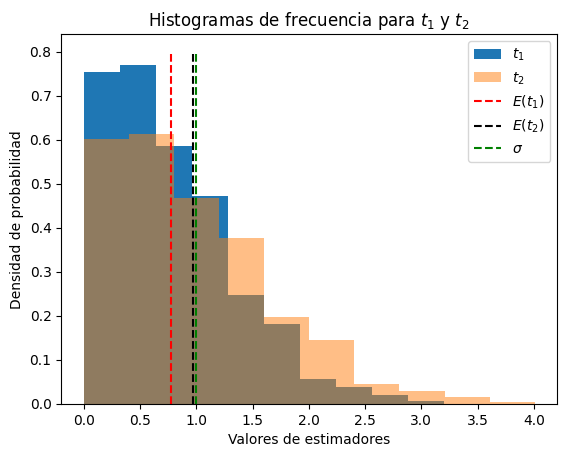

In [ ]:
plt.hist(t1,label='$t_1$',density = True)
plt.hist(t2,label='$t_2$',density = True,alpha = 0.5)
plt.vlines(np.mean(t1),0,0.8,label = '$E(t_1)$', linestyle='dashed',color='red')
plt.vlines(np.mean(t2),0,0.8,label = '$E(t_2)$',linestyle='dashed',color='black')
plt.vlines(np.sqrt(var),0,0.8,label = '$\sigma$',linestyle='dashed',color='green')
plt.title('Histogramas de frecuencia para $t_1$ y $t_2$ ')
plt.xlabel('Valores de estimadores')
plt.ylabel('Densidad de probabilidad')
plt.legend()

Calculamos también el sesgo de ambos estimadores, con la expresión

$$B(t_i) = E(t_i) - \sigma$$

In [ ]:
bias_t1 = np.mean(t1) - np.sqrt(var)
bias_t2 = np.mean(t2) - np.sqrt(var)

print('B(t1) = ',bias_t1)
print('B(t2) = ',bias_t2)

B(t1) =  -0.2251464401730061
B(t2) =  -0.02886507911958691


Tanto del gráfico como del cálculo del sesgo puede verse que $t_1$ es sesgado
pero $t_2$ no (o al menos que el sesgo de $t_2$ es mucho más chico).

Entiendo que no vimos una demostración de esto en clase, pero que si bien $s^2$ no es sesgado, tomarle la raíz cuadrada, que es una función no lineal, no da necesariamente un estimador sesgado.

En particular, según [Wikipedia](https://en.wikipedia.org/wiki/Unbiased_estimation_of_standard_deviation), el valor esperado de $t_1$ para una variable normal es

$$ E(\sqrt{s^2}) = c_4(n) \sigma $$

con $c_4(n)$ un factor de corrección, que en particular para $n=2$,
$$c_4(2) = \sqrt{\frac{2}{\pi}},$$

que explica por qué $t_1$ no es un estimador sesgado para la desviación estándar.





Por otro lado, se sabe que el estimador $s^2$ para la varianza es no sesgado, es decir que

$$
\langle s^2 \rangle =1
$$

Que $s$ sea no sesgado equivale a esperar que coincidan los valores medios de $s^2$ y $s$ como la unidad. Pero en general

$$
\langle s \rangle \neq \sqrt{\langle s^2 \rangle}
$$

Ya que el primer miembro es

$$
\int_0^\infty s f(s) d s
$$

Y el miembro derecho es

$$
\sqrt{\int_0^\infty s^2 f(s) d s}
$$

Que en general son distintos.